In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_weekly_data, load_supplementary
input_data, output_data = load_weekly_data()

## Data Engineering

In [2]:
# Clean tracking data
# Clean orientation and direction
input_data["o_clean"] = (-(input_data["o"] - 90)) % 360
input_data["dir_clean"] = (-(input_data["dir"] - 90)) % 360
# Set x on same scale
input_data["x_clean"] = np.where(
      input_data["play_direction"] == "left",
      120 - input_data["x"],
      input_data[
          "x"
      ], 
  )
# y, s, a alreday clean
input_data["y_clean"] = input_data["y"]
input_data["s_clean"] = input_data["s"]
input_data["a_clean"] = input_data["a"]
# Clean orientation based on play direction
input_data["o_clean"] = np.where(
    input_data["play_direction"] == "left", 180 - input_data["o_clean"], input_data["o_clean"]
)
# Clean orientation, direction, vx, and vy
input_data["o_clean"] = (input_data["o_clean"] + 360) % 360 
input_data["dir_clean"] = (input_data["dir_clean"] + 360) % 360
input_data["dir_radians"] = np.radians(input_data["dir_clean"])
input_data["v_x"] = input_data["s_clean"] * np.cos(input_data["dir_radians"])
input_data["v_y"] = input_data["s_clean"] * np.sin(input_data["dir_radians"])

# Exploratory Data Analysis

In [3]:
df = input_data.copy()

df.columns

Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a',
       'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'wk',
       'o_clean', 'dir_clean', 'x_clean', 'y_clean', 's_clean', 'a_clean',
       'dir_radians', 'v_x', 'v_y'],
      dtype='object')

In [4]:
numeric = ["x_clean", "y_clean", "s_clean", "a_clean", 
                "o_clean", "dir_clean", "v_x", "v_y"]

desc = df[numeric].describe().T
print(desc)

               count        mean         std        min         25%     50%  \
x_clean    4880579.0   60.827770   23.479941   1.370000   42.210000   57.59   
y_clean    4880579.0   26.811895   10.006199   0.620000   18.990000   26.85   
s_clean    4880579.0    3.019878    2.227939   0.000000    1.090000    2.72   
a_clean    4880579.0    2.118335    1.415794   0.000000    1.010000    1.92   
o_clean    4880579.0  180.372066  105.939815   0.000000  108.170000  180.15   
dir_clean  4880579.0  181.411971  108.218463   0.000000   92.460000  180.06   
v_x        4880579.0   -0.003630    2.967952 -10.309109   -1.656028    0.00   
v_y        4880579.0   -0.003528    2.296653 -10.049202   -0.950684    0.00   

                  75%         max  
x_clean     77.830000  119.860000  
y_clean     34.620000   52.880000  
s_clean      4.620000   12.530000  
a_clean      3.040000   17.120000  
o_clean    253.630000  359.990000  
dir_clean  272.910000  359.990000  
v_x          1.654853   10.128261  


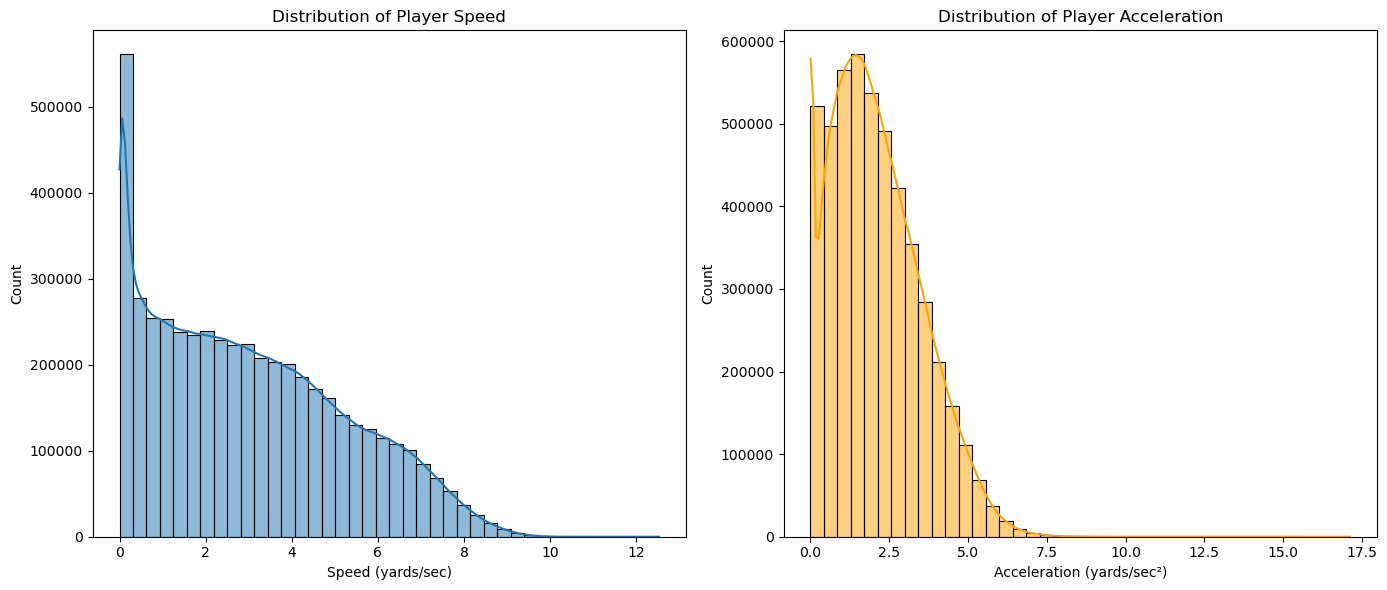

In [12]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.histplot(df["s_clean"], bins=40, kde=True)
plt.title("Distribution of Player Speed")
plt.xlabel("Speed (yards/sec)")

plt.subplot(1,2,2)
sns.histplot(df["a_clean"], bins=40, kde=True, color="orange")
plt.title("Distribution of Player Acceleration")
plt.xlabel("Acceleration (yards/sec²)")

plt.tight_layout()
plt.show()

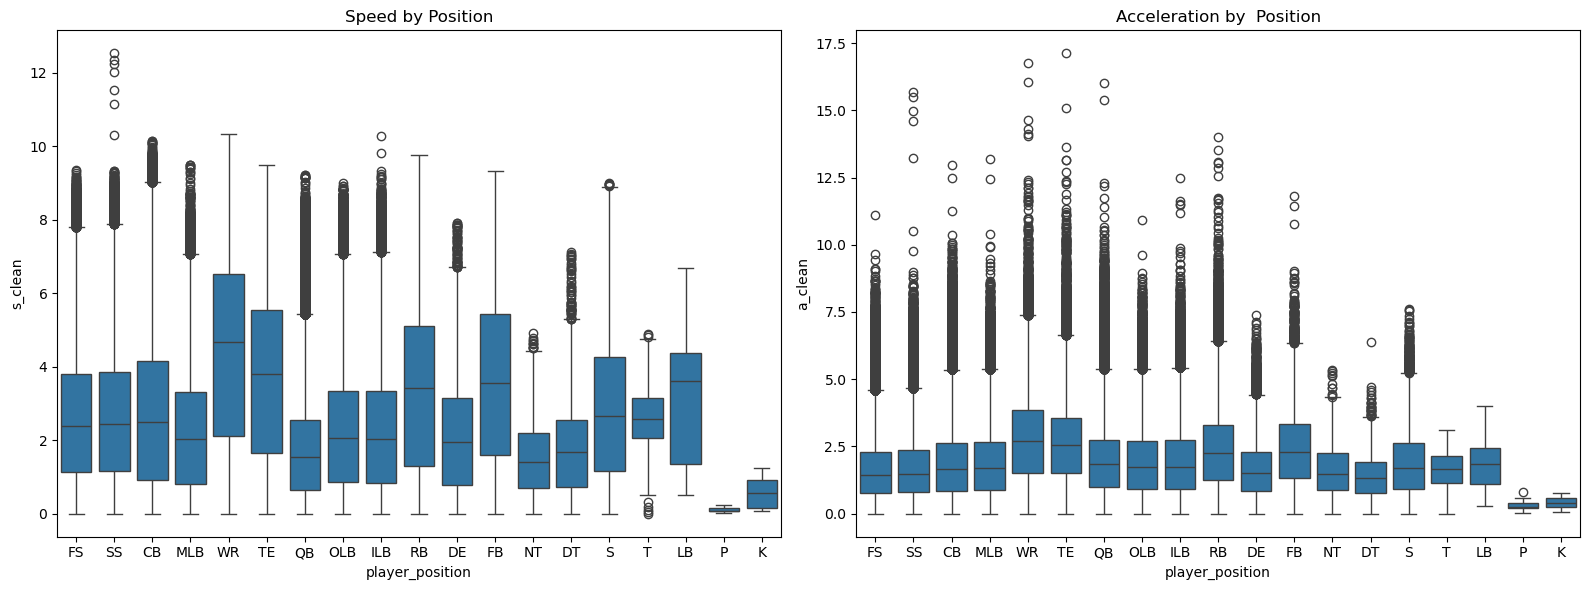

In [ ]:
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="player_position", y="s_clean")
plt.title("Speed by Position")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="player_position", y="a_clean")
plt.title("Acceleration by Position")

plt.tight_layout()
plt.show()

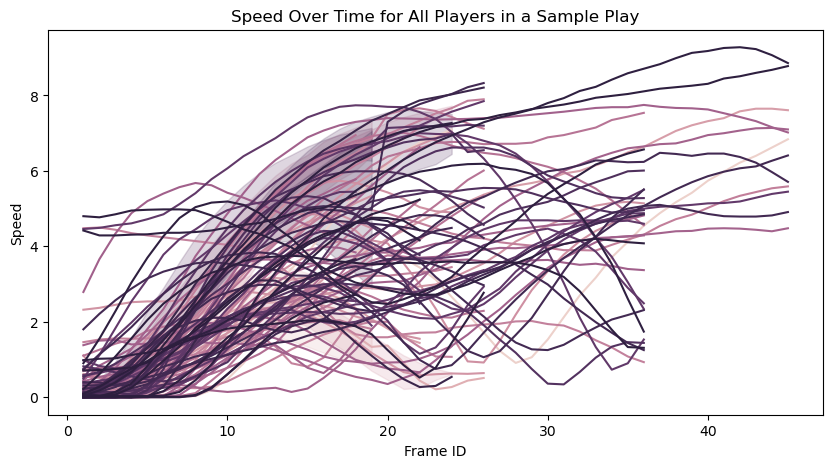

In [ ]:
sample_play = df[df["play_id"] == df["play_id"].iloc[0]]
sample_game = sample_play[sample_play["game_id"] == sample_play["game_id"].iloc[0]]

plt.figure(figsize=(10,5))
sns.lineplot(
    data=sample_play,
    x="frame_id",
    y="s_clean",
    hue="nfl_id",
    legend=False
)
plt.title("Speed Over Time for All Players During Sample game")
plt.xlabel("Frame ID")
plt.ylabel("Speed")
plt.show()


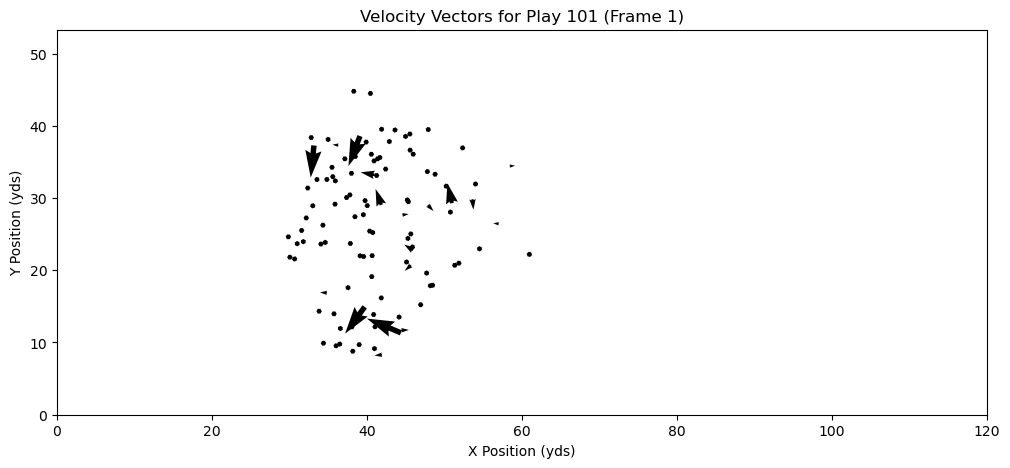

In [ ]:

play_id = df["play_id"].iloc[101]  

# specific play AND frame 1
play_frame = df[(df["play_id"] == play_id) & (df["frame_id"] == 1)].copy()

plt.figure(figsize=(12, 5))

plt.quiver(
    play_frame["x_clean"],
    play_frame["y_clean"],
    play_frame["v_x"],
    play_frame["v_y"],
    angles='xy',
    scale_units='xy',
    scale=1
)

plt.title(f"Velocity Vectors for Play {play_id} (Frame 1)")
plt.xlabel("X Position (yds)")
plt.ylabel("Y Position (yds)")
plt.xlim(0, 120)
plt.ylim(0, 53.3)

plt.show()


In [34]:

gameID = df["game_id"].iloc[101]
playID = df["play_id"].iloc[101]

df2 = df[(df["game_id"] == gameID) & (df["player_name"] == 'Jared Goff')]
df2['absolute_yardline_number'].unique()

# df2['player_name'].unique()

array([ 42,  22,  31,  44,  86, 101,  85,  71,  51,  37,  64,  80,  76,
        68, 103,  87,  69,  97,  77,  33,  63])

In [20]:
playIDRavens = df[(df['game_id'] == 2023123000)]
playIDRavens

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,wk,o_clean,dir_clean,x_clean,y_clean,s_clean,a_clean,dir_radians,v_x,v_y
4366451,2023123000,78,False,54632,1,right,35,DaRon Bland,5-11,206,...,17,262.94,281.88,42.10,42.40,2.42,0.33,4.919734,0.498188,-2.368166
4366452,2023123000,78,False,54632,2,right,35,DaRon Bland,5-11,206,...,17,256.12,281.09,42.15,42.17,2.45,0.20,4.905946,0.471259,-2.404249
4366453,2023123000,78,False,54632,3,right,35,DaRon Bland,5-11,206,...,17,249.09,280.72,42.19,41.92,2.49,0.11,4.899488,0.463164,-2.446544
4366454,2023123000,78,False,54632,4,right,35,DaRon Bland,5-11,206,...,17,240.41,281.38,42.24,41.68,2.51,0.08,4.911007,0.495261,-2.460654
4366455,2023123000,78,False,54632,5,right,35,DaRon Bland,5-11,206,...,17,235.61,282.02,42.30,41.43,2.52,0.18,4.922178,0.524798,-2.464749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4386328,2023123000,4062,True,53541,15,right,99,Amon-Ra St. Brown,6-1,195,...,17,315.94,324.62,100.83,11.66,5.85,2.25,5.665688,4.769680,-3.387130
4386329,2023123000,4062,True,53541,16,right,99,Amon-Ra St. Brown,6-1,195,...,17,312.49,320.58,101.30,11.30,6.00,2.60,5.595177,4.635072,-3.810001
4386330,2023123000,4062,True,53541,17,right,99,Amon-Ra St. Brown,6-1,195,...,17,309.54,317.38,101.75,10.90,6.04,2.64,5.539326,4.444599,-4.089883
4386331,2023123000,4062,True,53541,18,right,99,Amon-Ra St. Brown,6-1,195,...,17,301.91,314.07,102.18,10.47,6.04,2.74,5.481556,4.201042,-4.339683
